# Progetto Architetture Dati: Impatto della Data Quality sui Modelli di Machine Learning
---
---

## Obiettivo del Progetto di Architetture Dati

In ambito aziendale e nelle moderne architetture dati, raramente i modelli di Machine Learning in produzione vengono alimentati con dati perfetti. Sensori malfunzionanti, errori di join, bug nelle API o inserimenti manuali errati sporcano costantemente il flusso informativo.

L'obiettivo di questo progetto è **certificare la robustezza della nostra Rete Neurale** misurando empiricamente e statisticamente il degrado delle sue performance al variare della Data Quality. Il lavoro si articola nei seguenti 5 step:


### **Step Operativi**
Il lavoro è stato suddiviso in 5 fasi logiche:
1. **Preparazione e Baseline Analysis**: Isolamento del modello predittivo, setup temporale per l'addestramento e calcolo del payload di metriche avanzate sui dati puliti per stabilire il benchmark di riferimento (Baseline).
2. **Stress Test Coerenza Logica:** Simulazione di scenari in cui i dati perdono la loro validità semantica o entrano in contraddizione. L'obiettivo è misurare il rischio di Overfitting causato da informazioni illogiche.
3. **Stress Test Accuratezza del Dato:** niezione progressiva di rumore statistico e valori anomali estremi per valutare la Fault Tolerance dell'algoritmo e lo spostamento del suo "peso decisionale" (Feature Importance).
4. **Stress Test Completezza e Anomalie Asincrone:** Simulazione di guasti architetturali legati a carenza di informazioni e diseallineamenti temporali del dato.
5. **Analisi e Conclusioni Finali:** Valutazione complessiva della resilienza del modello e quantificazione dell'impatto tecnico ed economico causato dalla scarsa Data Quality.

### **Architettura del Repository**
Il progetto è strutturato come segue:

```text
Architetture-Dati-Progetto/
├── data/
│   ├── clean/
│   │   └── dataset_ml_ready.csv                # Dataset originale pulito (Baseline)
│   └── dirty/
│       └── dataset_*.csv                       # Dataset corrotti generati per ogni step di degrado 
│
├── doc/
│   ├── Architetture-Dati report.ipynb          # Report e relazione finale del progetto
│   ├── Presentazione tennis-prediction.pptx    # Presentazione progetto originale
│   └── tennis-prediction reporti.ipynb         # Report progetto originale
│ 
├── results/
│   ├── risultati_*.json                        # Cache delle metriche per ogni esperimento
│   └── plots/
│       └── *.png / *.jpg                       # Dashboard e grafici generati automaticamente 
│
├── src/
│   ├── baseline_data_quality.py                # Motore MLP, setup dello split temporale e salvataggio Baseline
│   ├── coerenza.py / plot_coerenza.py          # Script per gli esperimenti di Coerenza
│   ├── accuratezza.py / plot_accuratezza.py    # Script per gli esperimenti di Accuratezza
│   ├── completezza.py / plot_completezza.py    # Script per gli esperimenti di Completezza/Tempestività
│   └── pydeequ_compare.py                      # Data Profiling per scansionare i dataset in data/dirty/
│
├── requirements.txt                            # Dipendenze Python
└── README.md                                   # Documentazione tecnica per l'esecuzione del progetto


---

## Introduzione e Background: ATP Tennis Prediction

Il punto di partenza di questo elaborato è un progetto di Machine Learning precedentemente sviluppato, finalizzato alla previsione dell'esito dei match di tennis ATP dal 2000 al 2024. 

Nel progetto originale, abbiamo costruito una complessa pipeline di Data Preparation per estrarre e calcolare oltre 30 feature storiche e prestazionali per ogni giocatore. Tra le metriche più importanti figurano:
- **Differenziale ELO** globale e per superficie.
- **Forma Recente** misurata in percentuale di vittorie nelle ultime 5, 25 e 50 partite.
- **Metriche di Efficienza** rappresentate dalla percentuale di prime di servizio vincenti, palle break salvate.
- **Fattori Fisici** come età, altezza, mano dominante.

Il modello definitivo scelto è stato una **Rete Neurale Multilayer Perceptron** con architettura `(128, 128, 64, 32)` e regolarizzazione `alpha=0.01`. Addestrata sui dati scalati dal 2000 al 2022, la rete ha raggiunto un'accuratezza solida e stabile (tra il 65% e il 71% a seconda delle configurazioni) sul Test Set comprendente tutte le partite degli anni 2023 e 2024. Infine è stata fatta una validazione finale calcolando l'accuracy del nostro modello simulando il torneo degli Australian Open 2025 e ottenendo gli stessi valori per le metriche riscontrate sul Test Set. 

Per maggiori dettagli sul modello utilizzato è stato incluso il report del progetto in doc/tennis-prediction report.ipynb e l'intero progetto è consultabile al link:  [https://github.com/ilBiondo06/ML-Tennis-Prediction](https://github.com/ilBiondo06/ML-Tennis-Prediction)

---
---

## 1. Preparazione e Baseline Analysis

In questo primo stadio dell'esperimento, prepariamo l'infrastruttura tecnica e calcoliamo la **Baseline**. La Baseline rappresenta l'accuratezza del modello su dati "puliti" e servirà come termine di paragone per misurare il degrado delle performance nelle fasi successive. Al fine di una misurazione efficiente sono state estratte le sezioni di codice utili al nostro progetto dal progetto tennis-prediction e sono state racchiuse in metodi da poter chiamare all'occorrenza per gli allenamenti che verranno fatti durante ogni esperimento, e sono stati inseriti nello script `baseline_data_quality.py`.
Inoltre, per catturare a pieno il reale impatto del degrado dei dati, la nostra Baseline non si limita alla sola misurazione dell'Accuratezza di test. Il motore di valutazione è stato ingegnerizzato per estrarre ad ogni esecuzione un payload di **metriche avanzate**:
* **Generalization Gap:** Monitoriamo simultaneamente le performance sia sul Train che sul Test per rilevare eventuali fenomeni patologici di *Overfitting sul rumore* indotti dalla corruzione dei dati.
* **Confidenza Predittiva:** Oltre all'esito binario della partita, estraiamo la probabilità media con cui la rete è "certa" delle proprie previsioni, misurando come l'incoerenza dei dati influisca sul livello di dubbio dell'algoritmo.
* **Costo Computazionale:** Registriamo il tempo netto di addestramento (in secondi) per quantificare l'impatto economico e infrastrutturale che i dati sporchi causano in fase di convergenza della Loss Curve.

Infine, in fase di istanziazione della Rete Neurale (MLP Classifier), **è stato deliberatamente rimosso il seed fisso di inizializzazione** (`random_state=None`). Questa fondamentale scelta metodologica fa sì che i pesi sinaptici iniziali varino in modo stocastico. Eseguendo 10 iterazioni (*K-Runs*) per ogni singolo step di degrado, possiamo così calcolare la *vera* deviazione standard delle metriche, riuscendo a isolare la fisiologica incertezza del modello dall'instabilità critica causata dalla scarsa Data Quality.


### 1.1 Calcolo della Baseline
In questo primo step operativo, procediamo con l'importazione delle librerie fondamentali per la manipolazione dei dati (`pandas`, `numpy`) e per la costruzione della pipeline di Machine Learning tramite *scikit-learn* (`MLPClassifier`, `StandardScaler`). A livello architetturale, abbiamo definito una costante globale denominata `FEATURES` che contiene l'elenco esatto delle sole 34 variabili in input alla rete neurale che verranno usate per l'allenamento.

Inoltre importiamo tre funzioni per garantirne la riusabilità durante i loop di test.

1. **`get_train_test_split`:**
   Questa funzione si occupa di caricare il dataset e separare i dati di addestramento da quelli di test. A livello metodologico, abbiamo optato per uno Split Temporale: usiamo i dati storici fino al 31/12/2022 per il training e blindiamo le stagioni 2023-2024 per il test. Questo approccio è fondamentale nei dati sportivi per evitare che il modello impari dal "futuro". Inoltre, gestisce fisiologici valori mancanti iniziali (`fillna(0)`).

2. **`train_and_evaluate_mlp`:**
   Questa funzione si occupa dell'addestramento del modello. Riceve i dati, applica la standardizzazione e addestra la nostra rete neurale di riferimento (`MLPClassifier` con architettura 128-128-64-32). 
   *Nota Architetturale:* È fondamentale osservare che lo `StandardScaler` viene "fittato" (`fit_transform`) **esclusivamente sul Training Set**. Il Test Set viene solo trasformato (`transform`). Questa accortezza previene **Data Leakage**, garantendo che la valutazione del modello sia non influenzata dai risultati.

3. **`get_or_compute_baseline`:**
   Questa funzione agisce come un sistema di persistenza su disco. Poiché l'addestramento della Baseline richiede tempo, la funzione verifica la presenza dei risultati nel file locale `baseline_metrics.json`. Se esiste, recupera l'intero dizionario delle metriche istantaneamente; in caso contrario, avvia l'addestramento, estrae le metriche avanzate e salva il payload.

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione per importare i nostri script dalla cartella 'src'
sys.path.append(os.path.abspath('../src'))

# Importiamo le funzioni dal nostro motore logico
from baseline_data_quality import get_train_test_split, train_and_evaluate_mlp, get_or_compute_baseline, FEATURES

All'interno di questo blocco andiamo ad eseguire il Training e il Testing del nostro modello, l'addestramento viene eseguito sui dati "puliti" e i log a schermo confermano il corretto partizionamento dei record. Il valore di `baseline_acc` ottenuto in questo passaggio diventerà la nostra "Baseline": il tetto massimo di performance rispetto al quale misureremo e valuteremo tutti i futuri degradi causati dalla scarsa Data Quality.

In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../src'))

from baseline_data_quality import get_train_test_split, train_and_evaluate_mlp, get_or_compute_baseline, load_baseline_cache, FEATURES

print("--- INIZIO PIPELINE DATA QUALITY ---")
dataset_path = "../data/clean/dataset_ml_ready.csv"
try:
    get_or_compute_baseline(dataset_path)
    metrics = load_baseline_cache()
    
    if metrics:
        gap = metrics['acc_train'] - metrics['accuracy']
        
        print("\n" + "="*45)
        print(" METRICHE AVANZATE DELLA BASELINE")
        print("="*45)
        print(f" Accuratezza Test: {metrics['accuracy']:.2%}")
        print(f" Accuratezza Train: {metrics['acc_train']:.2%}")
        print(f" Generalization Gap: {gap:.2%}")
        print(f" Confidenza Predittiva: {metrics['confidenza']:.2%}")
        print(f" Tempo di addestramento: {metrics['time']:.2f} secondi")
        print(f" Epoche per convergere: {metrics['n_iter']}")
        print("="*45 + "\n")
    else:
        print("Errore: Impossibile caricare le metriche avanzate.")
        
except FileNotFoundError:
    print(f"\nERRORE: file {dataset_path} non trovato")
except Exception as e:
    print(f"\nErrore durante l'esecuzione: {e}")

--- INIZIO PIPELINE DATA QUALITY ---

 METRICHE AVANZATE DELLA BASELINE
 Accuratezza Test: 65.73%
 Accuratezza Train: 68.97%
 Generalization Gap: 3.24%
 Confidenza Predittiva: 66.61%
 Tempo di addestramento: 23.85 secondi
 Epoche per convergere: 19



### 1.2 Studio delle Feature Importance
Prima di procedere con l'iniezione del rumore, è fondamentale comprendere come la Rete Neurale distribuisca il proprio "peso decisionale" sulle 34 variabili disponibili. Essendo la MLP (Multilayer Perceptron) un modello *Black Box*, utilizziamo la tecnica della **Permutation Importance** per svelarne le logiche interne.

Il processo consiste nel prendere una singola variabile all'interno del Test Set, rimescolarne casualmente i valori per distruggerne il senso logico, e misurare di quanto crolla l'accuratezza predittiva del modello. Più alto è il calo di accuratezza (visualizzato sull'asse X del grafico sottostante), maggiore è l'importanza di quella variabile. Le stanghette nere rappresentano la deviazione standard calcolata su 10 iterazioni di rimescolamento.

Dal grafico emerge chiaramente che il differenziale ELO (`DIFF_ELO`) è la metrica dominante. Tuttavia, si osserva che anche variabili come l'età (`diff_age`), la differenza di ranking (`ATP_RANK_DIFF`) e l'ELO sulla singola superficie (`DIFF_SURF_ELO`) possiedono un peso decisionale significativo. Questo significa che le informazioni fornite al modello sono in parte ridondanti: se una variabile dovesse subire gravi problemi di Data Quality, la Rete Neurale potrebbe essere in grado di compensare l'errore ri-distribuendo la sua attenzione sulle altre variabili correlate, arginando così il guasto sistemico.

Caricamento dati per ispezione...


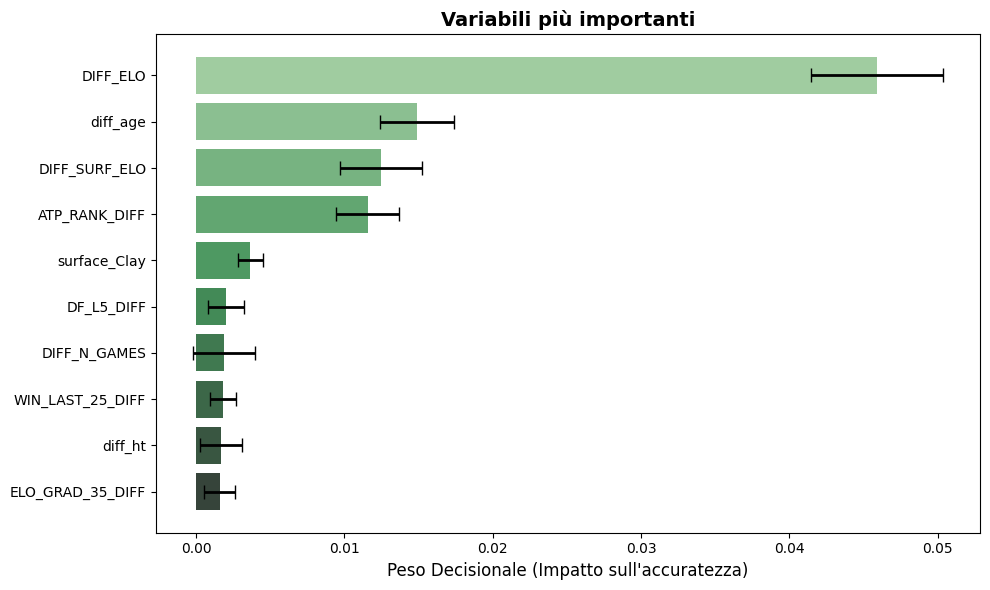

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

print("Caricamento dati per ispezione...")
dataset_path = "../data/clean/dataset_ml_ready.csv"
X_train_clean, y_train_clean, X_test_clean, y_test_clean = get_train_test_split(dataset_path)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

mlp_baseline = MLPClassifier(hidden_layer_sizes=(128, 128, 64, 32), activation='relu', 
                             alpha=0.01, max_iter=150, early_stopping=True)
mlp_baseline.fit(X_train_scaled, y_train_clean)

result = permutation_importance(mlp_baseline, X_test_scaled, y_test_clean, n_repeats=10, random_state=42, n_jobs=-1)

importanza_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importanza': result.importances_mean,
    'Deviazione': result.importances_std
}).sort_values(by='Importanza', ascending=False)

top_features = importanza_df.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x='Importanza', y='Feature', data=top_features, palette='Greens_d')

plt.errorbar(x=top_features['Importanza'], 
             y=np.arange(len(top_features)), 
             xerr=top_features['Deviazione'], 
             fmt='none', c='black', capsize=5, elinewidth=2)

plt.title('Variabili più importanti', fontsize=14, fontweight='bold')
plt.xlabel('Peso Decisionale (Impatto sull\'accuratezza)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

### 1.3 Visualizzazione dello Stato della Baseline

Per completare l'analisi del nostro modello di riferimento, visualizziamo graficamente il suo stato di salute prima dell'iniezione delle anomalie. 

Dal file di cache (`baseline_metrics.json`) estraiamo due viste fondamentali:
1. **La Matrice di Confusione:** Conferma un bilanciamento eccellente tra le previsioni corrette di vittoria e sconfitta.
2. **La Loss Curve (Curva di Errore):** Mostra una discesa fluida e rapida, segno che la Rete Neurale sta estraendo pattern logici e coerenti dal dataset pulito senza incontrare "attrito" matematico.

Caricamento metriche di salute dalla cache...


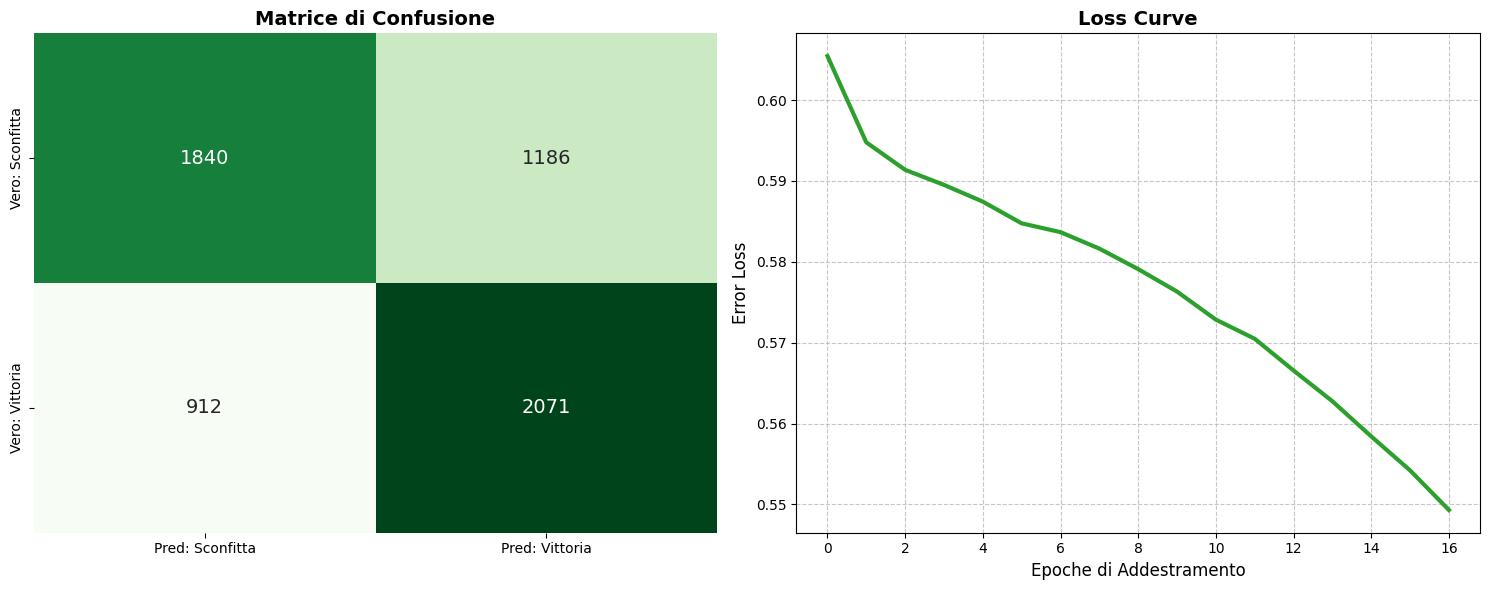

In [2]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("Caricamento metriche di salute dalla cache...")
cache_path = "../src/baseline_metrics.json"

if os.path.exists(cache_path):
    with open(cache_path, "r") as f:
        baseline_data = json.load(f)
        
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # --- 1. Matrice di Confusione Baseline ---
    cm = np.array(baseline_data['cm'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=['Pred: Sconfitta', 'Pred: Vittoria'],
                yticklabels=['Vero: Sconfitta', 'Vero: Vittoria'], 
                annot_kws={"size": 14}, ax=axes[0])
    axes[0].set_title('Matrice di Confusione', fontsize=14, fontweight='bold')

    # --- 2. Curva di Apprendimento (Loss Curve) ---
    loss_curve = baseline_data['loss_curve']
    epoche = baseline_data['n_iter']
    
    axes[1].plot(loss_curve, color='#2ca02c', linewidth=3)
    axes[1].set_title(f"Loss Curve", fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoche di Addestramento', fontsize=12)
    axes[1].set_ylabel('Error Loss', fontsize=12)
    axes[1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print(f"Errore: File {cache_path} non trovato. Esegui prima il calcolo della baseline.")

---
---
## 2. Stress Test Coerenza Logica

---
---

## 3.Stress Test Accuratezza del Dato

---
---
## 4. Stress Test Completezza e Anomalie Asincrone

In questo ultimo stress test, analizziamo i guasti architetturali legati alla disponibilità del dato. Nelle moderne architetture dati, la mancanza di informazioni o il ritardo nel loro aggiornamento sono problemi, spesso causati da sensori malfunzionanti, cadute di connessione o disallineamenti nelle cache dei database.

L'obiettivo è misurare l'impatto sul modello di queste carenze, analizzando scenari di "buio totale" (Blackout) e scenari di disallineamento temporale (Data Staleness), basandoci sulle definizioni formali delle dimensioni della Data Quality.

### 4.1 Metodologia di Degrado
Per esplorare queste dimensioni, abbiamo sviluppato e implementato due scenari di simulazione di guasto distinti:
* **Blackout Sistemico** (Completezza): La Completezza è definita come il grado in cui i dati associati a un'entità presentano valori per tutti gli attributi attesi in uno specifico contesto d'uso. Per simulare una violazione di questo principio, una percentuale controllata di record subisce la cancellazione in blocco di un'intera famiglia logica di variabili che nel nostro caso sono tutte le colonne relative all'ELO, sovrascritte con zeri. Questo scenario simula un guasto catastrofico di un modulo di calcolo a monte della pipeline.


In [ ]:
def missing_values_zero_systemic(X, percentage):
    """
    Simula la rottura del sistema che calcola l'Elo azzerando
    tutte le colonne correlate simultaneamente.
    """
    X_dirty = X.copy()
    n_changes = int(len(X_dirty) * percentage)
    
    # Identifica tutte le colonne derivanti dall'ELO
    elo_cols = [col for col in X_dirty.columns if 'elo' in col.lower()]
    idx = np.random.choice(X_dirty.index, n_changes, replace=False)
    
    # Iniezione del guasto (Blackout)
    for col in elo_cols:
        X_dirty.loc[idx, col] = 0.0
        
    return X_dirty


* **Data Staleness con 10 partite di lag**(Tempestività):
La Tempestività rappresenta il grado in cui i dati possiedono la giusta "età" (aggiornamento) all'interno di un contesto specifico. Per simulare un ritardo nelle pipeline, abbiamo iniettato dei valori obsoleti in una percentuale controllata di record. Per calcolare questi valori senza contaminare le informazioni tra giocatori diversi (il che avrebbe introdotto un errore di Accuratezza e non di Tempestività), abbiamo raggruppato i record per singolo tennista, estraendo la sua metrica arretrata di 10 partite. In questo modo, per le righe colpite dal guasto, il modello è costretto a prevedere l'esito della partita odierna basandosi sulla forma fisica che quel giocatore aveva mesi prima


In [ ]:
def temporaly_lag(X, percentage, lag=10):
    """
    Raggruppa lo storico per singolo giocatore (p1_id) e usa le sue 
    metriche Elo vecchie di 'lag' partite.
    """
    X_dirty = X.copy()
    n_changes = int(len(X_dirty) * percentage)
    
    elo_cols = [col for col in X_dirty.columns if 'elo' in col.lower()]
    idx = np.random.choice(X_dirty.index, n_changes, replace=False)
    
    # Iniezione del guasto temporale (Shift)
    for col in elo_cols:
        stale_values = X_dirty.groupby('p1_id')[col].shift(lag).bfill()
        X_dirty.loc[idx, col] = stale_values.loc[idx]
        
    return X_dirty


### 4.2 Analisi dell'Impatto
I risultati di questi stress test rivelano comportamenti profondamente diversi a seconda del tipo di guasto architetturale affrontato.

![performance assoluta](../results/plots/completezza_01_performance_assoluta.png)
Dal grafico delle performance assolute emerge un risultato controintuitivo e di grande valore analitico:

* Estrema Resilienza al Blackout: Sorprendentemente, la perdita quasi totale del totale del blocco ELO non causa un crollo verticale delle prestazioni. Anche a un livello di degrado critico dell'80%, l'Accuracy scende di appena uno 0.2% rispetto alla Baseline. Questo evidenzia un'eccellente Fault Tolerance del modello: di fronte a un dato palesemente vuoto o assente, la Rete Neurale azzera rapidamente i pesi di quella variabile e impara ad affidarsi in modo compensativo alle restanti feature intatte.

* Leggera Vulnerabilità al Lag-10: La curva arancione (Data Staleness) dimostra che l'obsolescenza è molto più distruttiva della mancanza del dato anche se non drasticamente. Arrivando all'80% di record non tempestivi, il modello perde oltre un punto percentuale (~1.2%). Questo accade perché i dati "vecchi" si presentano sintatticamente validi: la forma fisica di un giocatore può essere diversa rispetto al mese precedente ma non così differente da cambiare il risultato di alcune partite, di conseguenza il modello si fida della metrica ELO anche se viene leggermente ingannata da una rappresentazione obsoleta della forma fisica del tennista.

### 4.3 Matrici di confusione

Per comprendere intimamente come i modelli reagiscono ai due guasti, abbiamo analizzato l'evoluzione delle Matrici di Confusione, scoprendo che in entrambe le situazioni i modelli si comportano in maniera simile.

![matrice blackout](../results/plots/completezza_05_matrici_missing.png)

Osservando l'evoluzione della griglia del Blackout, emerge un comportamento non lineare che dimostra l'incredibile capacità di adattamento della Rete Neurale, riassumibile in tre fasi.
Al 10% di degrado, il modello assorbe il danno ricalibrandosi in una configurazione che visivamente appare stabile e sicura. Tuttavia, al 20% e 40% la rete va in confusione: fidandosi ancora della metrica ELO, cerca di compensare i "buchi" sbilanciandosi nettamente verso la predizione di vittorie (TP a 2097 e TN a 1267). Al 60%, il rumore diventa insostenibile e si assiste a una violenta "Oscillazione del Bias": il modello inverte brutalmente la tendenza, diventando pessimista e sovra-stimando le sconfitte.
La vera rivelazione avviene però all'80% di degrado: la matrice ritorna a una struttura visivamente quasi identica alla Baseline. Questo fenomeno avviene perché, di fronte a una colonna ormai quasi totalmente vuota, la rete smette di considerare l'ELO. Attraverso i suoi meccanismi di regolarizzazione, azzera implicitamente i pesi di quella variabile e si affida interamente alle restanti feature intatte. Il modello ritrova così la sua stabilità strutturale, pur operando con un'accuratezza globale lievemente ridotta.

<br>
<br>

![matrice lag](../results/plots/completezza_06_matrici_lag.png)

Anche nel caso della Data Staleness si assiste a un fenomeno di "Oscillazione del Bias" anche più marcato. Non essendoci "vuoti" evidenti nei dati, la rete viene attivamente ingannata da una storicità obsoleta. Al 20% di degrado, il modello subisce uno shock "ottimistico", sbilanciandosi innaturalmente sulla predizione di vittorie (2097 TP contro soli 1759 TN). Al 60%, il rumore temporale spinge la rete in iper-compensazione, facendole invertire brutalmente la tendenza verso il pessimismo (i TN schizzano a 2006,i TP crollano a 1831). Questa è la prova visiva dell'instabilità del modello: fidandosi ciecamente di una metrica non tempestiva, la rete sposta convulsamente il proprio confine decisionale, rendendo l'algoritmo meno affidabile.


### 4.4 Evoluzione della Feature Importance

Per comprendere se la Rete Neurale subisca passivamente il guasto architetturale o tenti di reagire, abbiamo estratto la Feature Importance dei modelli addestrati per ogni singolo step di degrado.

![Feature Importance Blackout](../results/plots/evoluzione_feature_completezza_blackout.png)

Nel caso della mancanza di dati, il passaggio di consegne tra le variabili è un processo di adattamento progressivo:

* Al 10% di degrado, la variabile DIFF_ELO mantiene saldamente il suo primato come metrica più influente.
* Tra il 20% e il 40%, si assiste a un vero e proprio sorpasso: l'impatto di DIFF_ELO si riduce drasticamente, mentre emergono la differenza di ranking (ATP_RANK_DIFF) e di età (diff_age) come nuove metriche guida.
* All'80%, il modello ha ormai isolato il guasto: l'importanza del differenziale ELO è ridotta quasi a zero. La rete lo ha completamente spento a livello sinaptico, dimostrando un'eccellente Fault Tolerance, e ha delegato il massimo peso decisionale alla differenza di ranking per mantenere le performance.

![Feature Importance Lag](../results/plots/evoluzione_feature_tempestivita_lag10.png)

Nel caso dei dati obsoleti, la riorganizzazione interna dei pesi è molto più repentina, a testimonianza dello shock temporale subito dal modello:

* Come per il Blackout, al 10% la rete cerca ancora di riporre la propria fiducia nel DIFF_ELO.
* Già dal 20%, tuttavia, il disallineamento della forma fisica dei giocatori si fa sentire: ATP_RANK_DIFF balza immediatamente al primo posto in termini di importanza, con diff_age in seconda posizione, mentre l'impatto dell'ELO crolla verticalmente.
* Dal 40% all'80%, la gerarchia decisionale si stabilizza in via definitiva. Il modello cessa di fare affidamento sul differenziale ELO, che risulta fuorviante, ancorandosi in modo fisso e costante al ranking e all'età per tentare disperatamente di compensare la violazione della tempestività